Lab 9 Clusterring Using Income Spent

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)
rows = 303

income = np.random.normal(245, 48, rows).astype(int)
spend = np.random.normal(150, 23, rows).astype(int)

dataset = pd.DataFrame({'INCOME': income, 'SPEND': spend})

In [3]:
print(dataset.shape)
print(dataset.describe())
print(dataset.head(5))

(303, 2)
           INCOME       SPEND
count  303.000000  303.000000
mean   244.148515  149.422442
std     47.133189   22.260196
min     89.000000   93.000000
25%    211.500000  133.500000
50%    247.000000  149.000000
75%    275.000000  164.000000
max    429.000000  220.000000
   INCOME  SPEND
0     268    164
1     238    149
2     276    152
3     318    179
4     233    136


In [4]:
Income = dataset['INCOME'].values
Spend = dataset['SPEND'].values
X = np.array(list(zip(Income, Spend)))
X

array([[268, 164],
       [238, 149],
       [276, 152],
       [318, 179],
       [233, 136],
       [233, 162],
       [320, 145],
       [281, 144],
       [222, 175],
       [271, 168],
       [222, 168],
       [222, 180],
       [256, 150],
       [153, 165],
       [162, 142],
       [218, 157],
       [196, 147],
       [260, 152],
       [201, 163],
       [177, 131],
       [315, 198],
       [234, 126],
       [248, 122],
       [176, 176],
       [218, 168],
       [250, 164],
       [189, 164],
       [263, 149],
       [216, 129],
       [230, 151],
       [216, 134],
       [333, 172],
       [244, 146],
       [194, 131],
       [284, 142],
       [186, 159],
       [255, 137],
       [150, 131],
       [181, 155],
       [254, 155],
       [280, 138],
       [253, 139],
       [239, 155],
       [230, 116],
       [174, 117],
       [210, 133],
       [222, 145],
       [295, 157],
       [261, 183],
       [160, 169],
       [260, 146],
       [226, 149],
       [212,

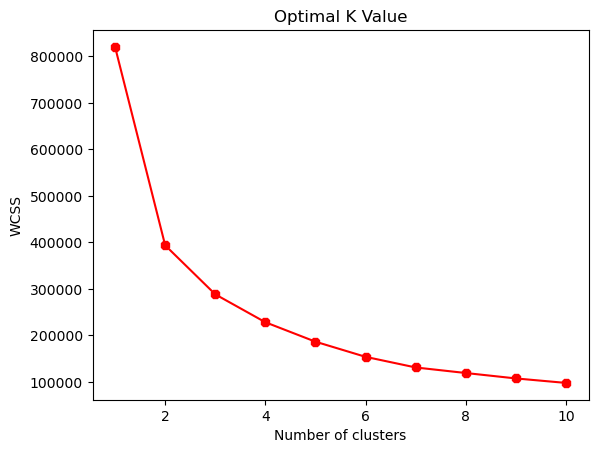

In [5]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, n_init=10, random_state=0) 
    km.fit(X)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss, color="red", marker="8")
plt.title('Optimal K Value')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [6]:
model = KMeans(n_clusters=4, n_init=10, random_state=0)
y_means = model.fit_predict(X)

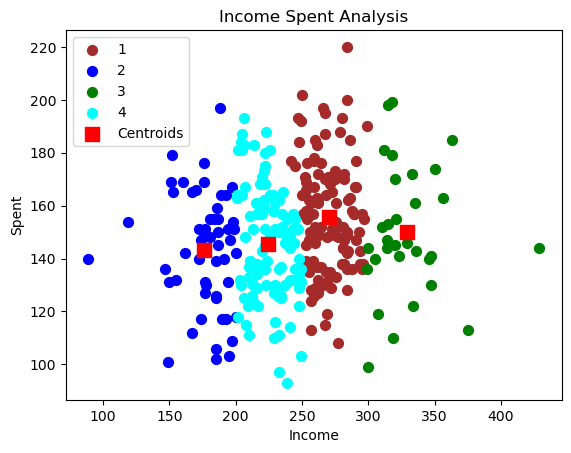

In [7]:
plt.scatter(X[y_means==0,0],X[y_means==0,1],s=50, c='brown',label='1')
plt.scatter(X[y_means==1,0],X[y_means==1,1],s=50, c='blue',label='2')
plt.scatter(X[y_means==2,0],X[y_means==2,1],s=50, c='green',label='3')
plt.scatter(X[y_means==3,0],X[y_means==3,1],s=50, c='cyan',label='4')
plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1],s=100,marker='s', c='red', label='Centroids')
plt.title('Income Spent Analysis')
plt.xlabel('Income')
plt.ylabel('Spent')
plt.legend()
plt.show()